In [126]:
input_num = 5
method1 = 'our'
method2 = 'exorcism'
# method2 = 'qiskit'

In [127]:
our_data = {}
with open(f'data/{method1}_rand_tcost_{input_num}.txt', 'r') as f:
        our_data = {int(k): int(v)
                 for line in f
                 for k, v in (line.strip().split(':'),)}

exorcism_data = {}
with open(f'data/{method2}_rand_tcost_{input_num}.txt', 'r') as f:
        exorcism_data = {int(k): int(v)
                 for line in f
                 for k, v in (line.strip().split(':'),)}

In [128]:
dif = {}
better, eqv, worse = 0, 0, 0
for k in exorcism_data:
    dif[k] = exorcism_data[k]-our_data[k]
    if dif[k]>0:
        better+=1
    elif dif[k]==0:
        eqv+=1
    else:
        worse+=1
dif_col = {}
for k in dif:
    if not dif[k] in dif_col:
        dif_col[dif[k]] = 1
    else:
        dif_col[dif[k]] += 1
sorted_dif_col = dict(sorted(dif_col.items()))
# print(sorted_dif_col)

print("****** Comparison of TDD-based Method Alg. 2 to Exorcism  ******")
# print(len(exorcism_data))
print(f"number of input variables: {input_num}")
print(f"lower  t-cost in {better}({better / len(exorcism_data) * 100}%) cases")
print(f"higher t-cost in {worse}({worse / len(exorcism_data) * 100}%) cases")
print(f"same   t-cost in {eqv}({eqv / len(exorcism_data) * 100}%) cases")
print("****** ******  ******")

****** Comparison of TDD-based Method Alg. 2 to Exorcism  ******
number of input variables: 5
lower  t-cost in 64371(80.46375%) cases
higher t-cost in 15442(19.302500000000002%) cases
same   t-cost in 187(0.23375%) cases
****** ******  ******


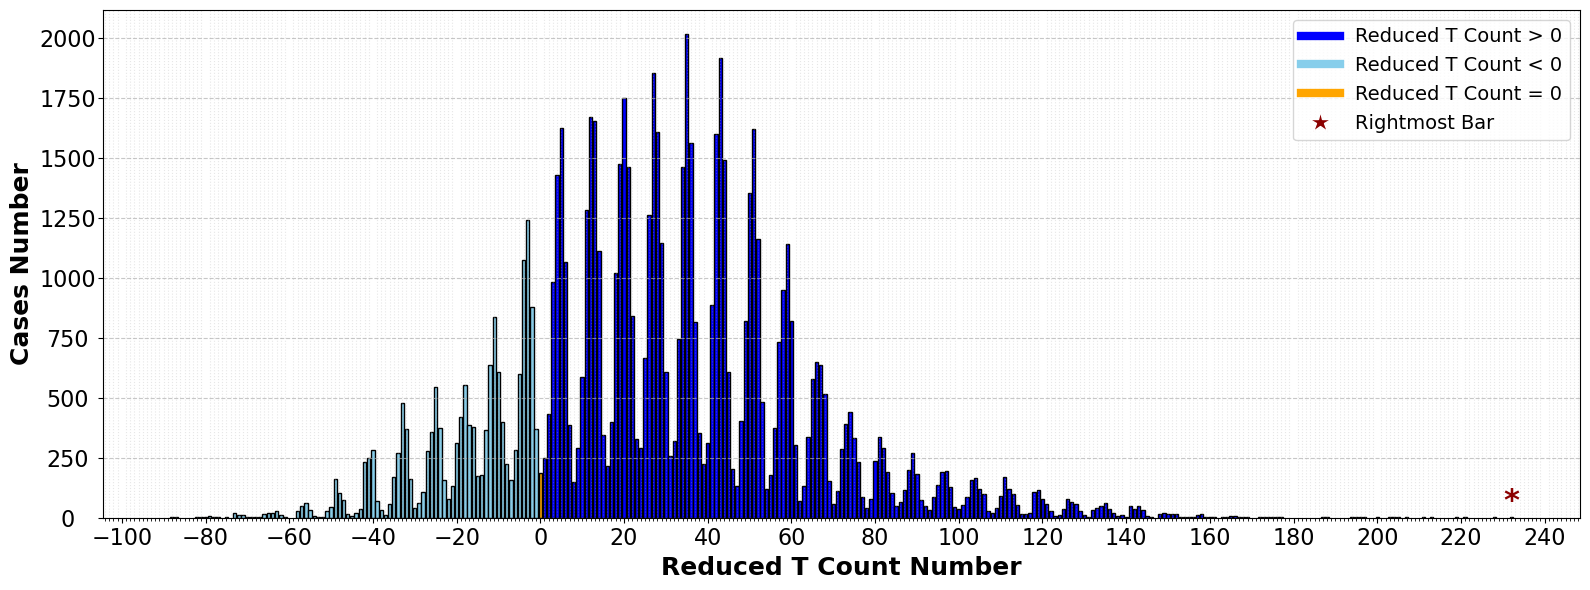

In [129]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# 原始数据
data = sorted_dif_col
# 提取键和值，并按键排序
sorted_keys = sorted(data.keys())
sorted_values = [data[key] for key in sorted_keys]

# 根据键的正负分配颜色：大于0为绿色，小于0为天蓝，0为橙色（突出显示）
colors = []
for key in sorted_keys:
    if key > 0:
        colors.append('blue')
    elif key < 0:
        colors.append('skyblue')
    else:
        colors.append('orange')  # 键为0时用橙色

# 设置画布
plt.figure(figsize=(16, 6))

# 绘制柱状图（指定颜色列表）
bars = plt.bar(sorted_keys, sorted_values, color=colors, edgecolor='black', width=0.8)




# 直接获取最右边柱子的索引（排序后列表的最后一个元素）
rightmost_idx = -1  # 列表最后一个元素的索引
rightmost_key = sorted_keys[rightmost_idx]
rightmost_value = sorted_values[rightmost_idx]

rightmost_bar = bars[rightmost_idx]
# 在柱子顶部添加红色星号，位置稍作调整确保不被裁剪
plt.text(
    rightmost_key,  # x坐标与柱子对齐
    rightmost_value + 8,  # y坐标向上偏移8，适配小值柱子
    '*',
    ha='center',
    va='bottom',
    fontsize=22,  # 星号放大，更醒目
    color='darkred',
    fontweight='bold'
)



# 添加标题和标签
# plt.title(f'Experiment Result of {input_num} Variable Boolean Functions', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Reduced T Count Number', fontsize=18, fontweight='bold')
plt.ylabel('Cases Number', fontsize=18, fontweight='bold')

# 设置x轴刻度间隔为2，添加次刻度
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_minor_locator(MultipleLocator(1))
ax.grid(axis='x', which='minor', linestyle=':', alpha=0.3)

# 优化标签显示
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.yticks(rotation=0, ha='center', fontsize=16)
ax.tick_params(axis='y', pad=22)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=6, label='Reduced T Count > 0'),
    Line2D([0], [0], color='skyblue', lw=6, label='Reduced T Count < 0'),
    Line2D([0], [0], color='orange', lw=6, label='Reduced T Count = 0'),
    Line2D([0], [0], marker='*', markersize=16, color='w', markerfacecolor='darkred', label='Rightmost Bar')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)
plt.tight_layout()

# plt.savefig(f'Experiment_{method1}_vs_{method2}_{input_num}_var.pdf', dpi=30000, bbox_inches='tight', format='pdf')
plt.show()

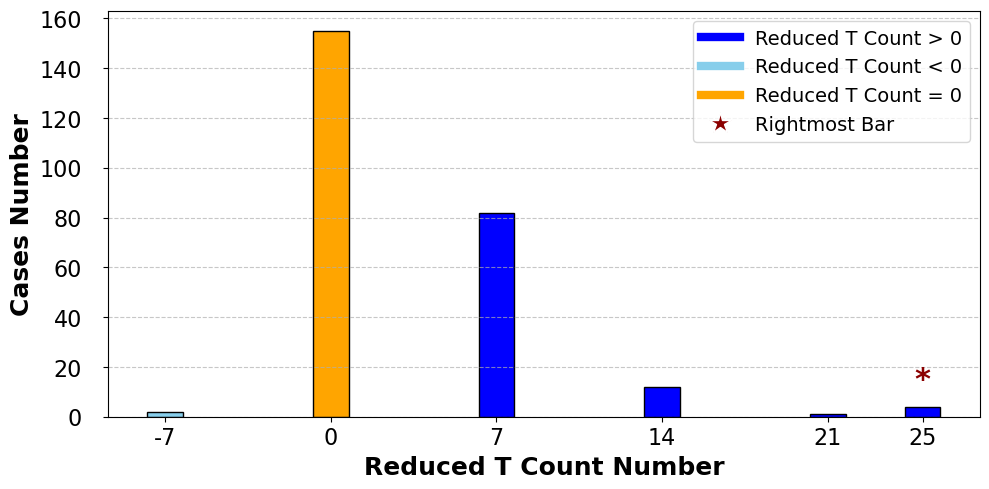

In [130]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

# 原始数据（仅包含有数据的键）
data = {-7: 2, 0: 155, 7: 82, 14: 12, 21: 1, 25: 4}

# 提取键和值，并按键排序（仅包含有数据的键）
sorted_keys = sorted(data.keys())
sorted_values = [data[key] for key in sorted_keys]

# 根据键的正负分配颜色
colors = []
for key in sorted_keys:
    if key > 0:
        colors.append('blue')
    elif key < 0:
        colors.append('skyblue')
    else:
        colors.append('orange')

# 设置画布
plt.figure(figsize=(10, 5))  # 缩小宽度，避免柱子过散

# 绘制柱状图（仅包含有数据的柱子）
bars = plt.bar(sorted_keys, sorted_values, color=colors, edgecolor='black', width=1.5)  # 适当加宽柱子

# 最右边柱子标注星号
rightmost_idx = -1
rightmost_key = sorted_keys[rightmost_idx]
rightmost_value = sorted_values[rightmost_idx]
plt.text(
    rightmost_key,
    rightmost_value + 5,  # 调整偏移量适配当前数据范围
    '*',
    ha='center',
    va='bottom',
    fontsize=22,
    color='darkred',
    fontweight='bold'
)

# 添加标题和标签
plt.xlabel('Reduced T Count Number', fontsize=18, fontweight='bold')
plt.ylabel('Cases Number', fontsize=18, fontweight='bold')

# 关键：x轴只显示有数据的键（固定刻度为sorted_keys）
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator(sorted_keys))  # 仅显示有数据的键作为刻度
plt.xticks(sorted_keys, sorted_keys, rotation=0, ha='center', fontsize=16)  # 刻度标签为数据中的键

# 优化y轴标签间距
plt.yticks(fontsize=16)
ax.tick_params(axis='y', pad=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 添加图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=6, label='Reduced T Count > 0'),
    Line2D([0], [0], color='skyblue', lw=6, label='Reduced T Count < 0'),
    Line2D([0], [0], color='orange', lw=6, label='Reduced T Count = 0'),
    Line2D([0], [0], marker='*', markersize=16, color='w', markerfacecolor='darkred', label='Rightmost Bar')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=14)

plt.tight_layout()
# plt.savefig(f'Experiment_3_var_2.pdf', dpi=3000, bbox_inches='tight', format='pdf')
plt.show()

In [131]:
t_r = 0
n = 0
for k in sorted_dif_col:
    if k>0:
        t_r+=k*sorted_dif_col[k]
        n+=sorted_dif_col[k]
print(t_r,n,t_r/n)

2550148 64371 39.61641111680726
